In [1]:
# ─────────────────────────────────────────────────────────
# CELL 1 — Imports
# ─────────────────────────────────────────────────────────
import numpy as np
import os, gc, shutil
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import r2_score

print("TF version :", tf.__version__)
print("GPU        :", tf.config.list_physical_devices('GPU'))

TF version : 2.10.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# ─────────────────────────────────────────────────────────
# CELL 2 — Paths and constants
# ─────────────────────────────────────────────────────────
DATA_FOLDER    = 'Ready_for_LSTM_v11'
client_names   = ['client_A', 'client_B1', 'client_B2', 'client_B3']

BATTERY_KWH    = 18.8    # BMW i3
AVG_EFFICIENCY = 0.15    # kWh/km

In [3]:
# ─────────────────────────────────────────────────────────
# CELL 3 — Verify shapes
# ─────────────────────────────────────────────────────────
print("Client data shapes:\n")
for name in client_names:
    folder = os.path.join(DATA_FOLDER, name)
    X = np.load(os.path.join(folder, 'X_train.npy'), mmap_mode='r')
    y = np.load(os.path.join(folder, 'y_train.npy'), mmap_mode='r')
    print(f"  {name} — X_train: {X.shape} | y_train: {y.shape} | SoC range: {y.min():.3f}→{y.max():.3f}")
    del X, y

gc.collect()

Client data shapes:

  client_A — X_train: (70147, 60, 16) | y_train: (70147,) | SoC range: 0.342→0.884
  client_B1 — X_train: (43679, 60, 16) | y_train: (43679,) | SoC range: 0.270→0.859
  client_B2 — X_train: (30983, 60, 16) | y_train: (30983,) | SoC range: 0.346→0.855
  client_B3 — X_train: (16787, 60, 16) | y_train: (16787,) | SoC range: 0.154→0.852


88

In [4]:
# ─────────────────────────────────────────────────────────
# CELL 4 — Build LSTM model
# Output has sigmoid — forces prediction between 0 and 1
# matching SoC fraction range
# ─────────────────────────────────────────────────────────
input_shape = (60, 16)   # 60 timesteps, 16 features

def build_lstm_model(input_shape):
    model = Sequential([
        tf.keras.Input(shape=input_shape),
        LSTM(128, return_sequences=True),
        Dropout(0.2),
        LSTM(64, return_sequences=True),
        Dropout(0.2),
        LSTM(32),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')   # sigmoid → output always 0-1 like SoC
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

global_model = build_lstm_model(input_shape)
global_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 60, 128)           74240     
                                                                 
 dropout (Dropout)           (None, 60, 128)           0         
                                                                 
 lstm_1 (LSTM)               (None, 60, 64)            49408     
                                                                 
 dropout_1 (Dropout)         (None, 60, 64)            0         
                                                                 
 lstm_2 (LSTM)               (None, 32)                12416     
                                                                 
 dense (Dense)               (None, 16)                528       
                                                                 
 dense_1 (Dense)             (None, 1)                 1

In [5]:
# ─────────────────────────────────────────────────────────
# CELL 5 — FedAvg
# ─────────────────────────────────────────────────────────
def federated_average(client_weights, client_sizes):
    total_samples = sum(client_sizes)
    avg_weights   = []
    for layer_idx in range(len(client_weights[0])):
        layer_avg = sum(
            client_weights[i][layer_idx] * (client_sizes[i] / total_samples)
            for i in range(len(client_weights))
        )
        avg_weights.append(layer_avg)
    return avg_weights

In [6]:
# ─────────────────────────────────────────────────────────
# CELL 6 — FL Training Loop
# ─────────────────────────────────────────────────────────
FL_ROUNDS    = 20
LOCAL_EPOCHS = 5
BATCH_SIZE   = 256

round_mae_history = []
local_model       = build_lstm_model(input_shape)

os.makedirs(os.path.join(DATA_FOLDER, 'checkpoints'), exist_ok=True)

for round_num in range(1, FL_ROUNDS + 1):

    print(f"\n========== FL Round {round_num}/{FL_ROUNDS} ==========")

    client_weight_list = []
    client_size_list   = []

    for name in client_names:
        folder  = os.path.join(DATA_FOLDER, name)
        X_train = np.load(os.path.join(folder, 'X_train.npy')).astype(np.float32)
        y_train = np.load(os.path.join(folder, 'y_train.npy')).astype(np.float32)

        local_model.set_weights(global_model.get_weights())
        local_model.fit(X_train, y_train,
                        epochs=LOCAL_EPOCHS,
                        batch_size=BATCH_SIZE,
                        verbose=0)

        client_weight_list.append(local_model.get_weights())
        client_size_list.append(len(X_train))
        print(f"  {name} done — {len(X_train)} samples")

        del X_train, y_train
        gc.collect()

    global_model.set_weights(federated_average(client_weight_list, client_size_list))
    del client_weight_list
    gc.collect()

    # Evaluate in SoC space
    all_mae = []
    for name in client_names:
        folder = os.path.join(DATA_FOLDER, name)
        X_test = np.load(os.path.join(folder, 'X_test.npy')).astype(np.float32)
        y_test = np.load(os.path.join(folder, 'y_test.npy')).astype(np.float32)
        _, mae = global_model.evaluate(X_test, y_test, verbose=0)
        all_mae.append(mae)
        del X_test, y_test
        gc.collect()

    avg_mae    = np.mean(all_mae)
    avg_mae_km = (avg_mae * BATTERY_KWH) / AVG_EFFICIENCY   # convert to km
    round_mae_history.append(avg_mae_km)
    print(f"  Avg MAE: {avg_mae:.4f} SoC | {avg_mae_km:.2f} km")

    # Checkpoint
    ckpt = os.path.join(DATA_FOLDER, 'checkpoints', f'global_round_{round_num}.weights.h5')
    global_model.save_weights(ckpt)
    print(f"  Checkpoint saved — round {round_num}")

del local_model
gc.collect()
print("\nFederated Learning complete.")


========== FL Round 1/20 ==========
  client_A done — 70147 samples
  client_B1 done — 43679 samples
  client_B2 done — 30983 samples
  client_B3 done — 16787 samples
  Avg MAE: 0.0937 SoC | 11.74 km
  Checkpoint saved — round 1

========== FL Round 2/20 ==========
  client_A done — 70147 samples
  client_B1 done — 43679 samples
  client_B2 done — 30983 samples
  client_B3 done — 16787 samples
  Avg MAE: 0.0307 SoC | 3.84 km
  Checkpoint saved — round 2

========== FL Round 3/20 ==========
  client_A done — 70147 samples
  client_B1 done — 43679 samples
  client_B2 done — 30983 samples
  client_B3 done — 16787 samples
  Avg MAE: 0.0303 SoC | 3.80 km
  Checkpoint saved — round 3

========== FL Round 4/20 ==========
  client_A done — 70147 samples
  client_B1 done — 43679 samples
  client_B2 done — 30983 samples
  client_B3 done — 16787 samples
  Avg MAE: 0.0335 SoC | 4.20 km
  Checkpoint saved — round 4

========== FL Round 5/20 ==========
  client_A done — 70147 samples
  client_B1 do

In [7]:
# ─────────────────────────────────────────────────────────
# CELL 7 — Per-client evaluation in km
# ─────────────────────────────────────────────────────────
print("Final Results — RDR in km:\n")

all_r2 = []

for name in client_names:
    folder     = os.path.join(DATA_FOLDER, name)
    X_test     = np.load(os.path.join(folder, 'X_test.npy')).astype(np.float32)
    y_test_km  = np.load(os.path.join(folder, 'y_test_km.npy')).astype(np.float32)

    y_pred_soc = global_model.predict(X_test, verbose=0).flatten()
    y_pred_km  = (y_pred_soc * BATTERY_KWH) / AVG_EFFICIENCY

    mae_km = np.mean(np.abs(y_pred_km - y_test_km))
    r2     = r2_score(y_test_km, y_pred_km)
    all_r2.append(r2)

    print(f"  {name}  →  R²: {r2:.4f}  |  MAE: {mae_km:.2f} km")

    del X_test, y_test_km
    gc.collect()

overall_r2 = np.mean(all_r2)
print(f"\n  Overall R²     : {overall_r2:.4f}")
print(f"  {'PASS ✓' if overall_r2 > 0.7 else 'FAIL ✗'} — threshold R² > 0.7")

Final Results — RDR in km:

  client_A  →  R²: 0.9240  |  MAE: 1.99 km
  client_B1  →  R²: 0.7996  |  MAE: 5.55 km
  client_B2  →  R²: 0.7702  |  MAE: 4.96 km
  client_B3  →  R²: 0.8701  |  MAE: 3.85 km

  Overall R²     : 0.8410
  PASS ✓ — threshold R² > 0.7


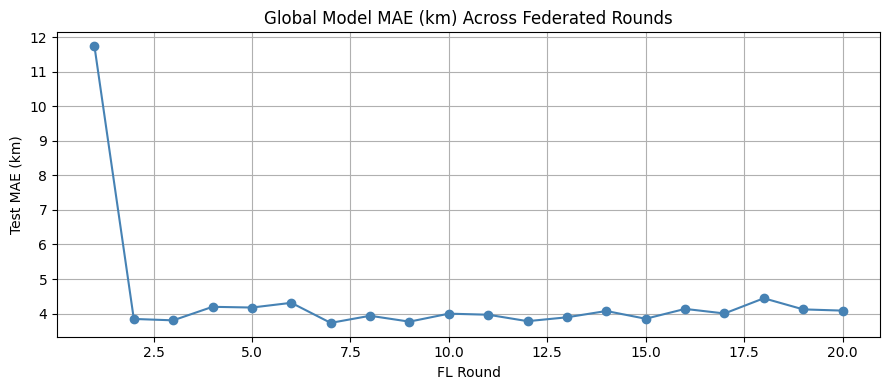

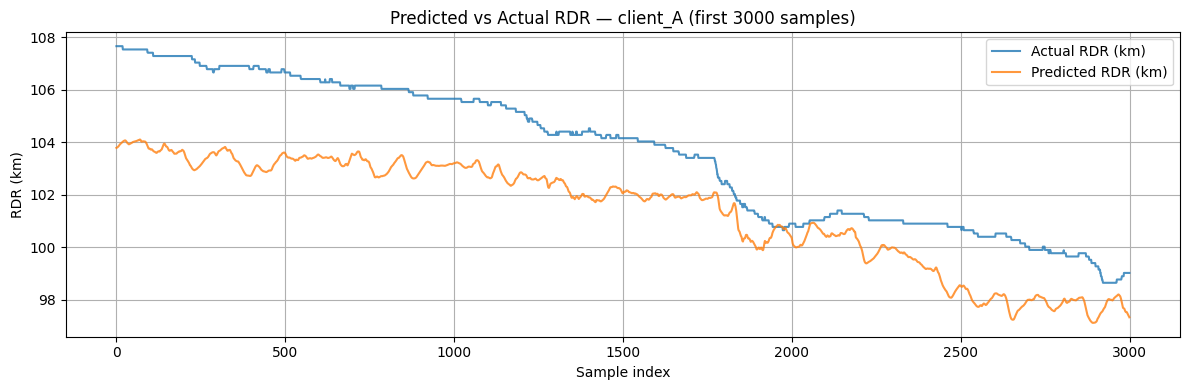

8378

In [8]:
# ─────────────────────────────────────────────────────────
# CELL 8 — Plots
# ─────────────────────────────────────────────────────────

# Plot 1 — MAE in km across FL rounds
plt.figure(figsize=(9, 4))
plt.plot(range(1, FL_ROUNDS + 1), round_mae_history, marker='o', color='steelblue')
plt.title("Global Model MAE (km) Across Federated Rounds")
plt.xlabel("FL Round")
plt.ylabel("Test MAE (km)")
plt.grid(True)
plt.tight_layout()
plt.savefig("/content/fl_round_mae_km.png", dpi=150)
plt.show()

# Plot 2 — Predicted vs Actual RDR in km for client_A
folder     = os.path.join(DATA_FOLDER, 'client_A')
X_test     = np.load(os.path.join(folder, 'X_test.npy')).astype(np.float32)
y_test_km  = np.load(os.path.join(folder, 'y_test_km.npy')).astype(np.float32)

y_pred_soc = global_model.predict(X_test, verbose=0).flatten()
y_pred_km  = (y_pred_soc * BATTERY_KWH) / AVG_EFFICIENCY

plt.figure(figsize=(12, 4))
plt.plot(y_test_km[:3000],  label='Actual RDR (km)',    alpha=0.8)
plt.plot(y_pred_km[:3000],  label='Predicted RDR (km)', alpha=0.8)
plt.title("Predicted vs Actual RDR — client_A (first 3000 samples)")
plt.xlabel("Sample index")
plt.ylabel("RDR (km)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("/content/rdr_prediction_km.png", dpi=150)
plt.show()

del X_test, y_test_km
gc.collect()

In [ ]:
# ─────────────────────────────────────────────────────────
# Extract weights from the trained FL model
# ─────────────────────────────────────────────────────────

# global_model layers: LSTM(128) → LSTM(64) → LSTM(32) → Dense(16) → Dense(1)

lstm1 = global_model.layers[0]   # LSTM 128
lstm2 = global_model.layers[2]   # LSTM 64   (index 1 is Dropout)
lstm3 = global_model.layers[4]   # LSTM 32   (index 3 is Dropout)
dense1 = global_model.layers[5]  # Dense 16
dense2 = global_model.layers[6]  # Dense 1

# Each LSTM layer returns [kernel, recurrent_kernel, bias]
W1, U1, b1 = lstm1.get_weights()
W2, U2, b2 = lstm2.get_weights()
W3, U3, b3 = lstm3.get_weights()
Wd1, bd1   = dense1.get_weights()
Wd2, bd2   = dense2.get_weights()

print("LSTM1 kernel shape:", W1.shape, "| recurrent:", U1.shape, "| bias:", b1.shape)
print("LSTM2 kernel shape:", W2.shape, "| recurrent:", U2.shape, "| bias:", b2.shape)
print("LSTM3 kernel shape:", W3.shape, "| recurrent:", U3.shape, "| bias:", b3.shape)
print("Dense1:", Wd1.shape, bd1.shape)
print("Dense2:", Wd2.shape, bd2.shape)